<a href="https://colab.research.google.com/github/rat626/Left-or-Right/blob/main/BrainTrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


import scipy.io as sio
import numpy as np


mat_data = sio.loadmat("/content/drive/MyDrive/StrokeOrthosis/parsed_P01T.mat")
#you are making a numpy array of the specific variable - in this case - the rawdata matrix - within mat_data, which is your entire file
numpy_array = np.array(mat_data['RawEEGData'])
print(numpy_array)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[[[  74.75900269   81.15424347  -13.50206089 ...    3.07421613
    -88.30847168  -77.60597229]
  [  63.50773239   81.22631073   -0.78543532 ...   14.60716915
    -65.50229645  -62.39150238]
  [  71.66365814   76.35163116   -8.08204174 ...    1.69825745
    -66.19307709  -48.29434586]
  ...
  [  58.88269806  110.96170807   36.75502777 ...   25.94512177
    -83.4521637   -96.60771942]
  [  65.50759888   91.69872284   11.69909954 ...    8.06597042
    -82.13864899  -77.25291443]
  [  66.91001892   87.16403961    2.31107616 ...   10.33413887
    -66.65511322  -66.51851654]]

 [[ -85.04611206  -28.84659958   87.10630798 ...  120.40718842
     64.69408417  -66.08109283]
  [ -76.38872528  -31.71484375   67.99704742 ...  107.9973526
     62.75708771  -55.00587845]
  [ -76.73183441  -17.66407394   79.23066711 ...  100.41035461
     43.68867111  -66.23646545]
  ...
  [

In [2]:
#now - convert this into an mne array so that you can get frequency bands/psd

!pip install mne
import mne

sampling_freq = 512
channel_names = ['F3', 'FC3', 'C3', 'CP3', 'P3', 'FCz', 'CPz', 'F4', 'FC4', 'C4', 'CP4', 'P4']
channel_types = ['eeg'] * 12

#when you do mne.create_info - this is like the constructor - you are setting each instance variable = to the specific values we want
info = mne.create_info(ch_names=channel_names, sfreq=sampling_freq, ch_types=channel_types)

# Reshape numpy_array to (n_channels, n_samples) as required by RawArray
# Original shape: (epochs, channels, samples_per_epoch)
# Desired shape: (channels, epochs * samples_per_epoch)
reshaped_numpy_array = numpy_array.transpose(1, 0, 2).reshape(info['nchan'], -1)

labeledarray = mne.io.RawArray(reshaped_numpy_array, info)

#montage maps each electrode to specific xyz coordinates on the head
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 82.2 MB/s eta 0:00:00
Creating RawArray with float64 data, n_channels=12, n_times=327680
    Range : 0 ... 327679 =      0.000 ...   639.998 secs
Ready.


<Info | 8 non-empty values
 bads: []
 ch_names: F3, FC3, C3, CP3, P3, FCz, CPz, F4, FC4, C4, CP4, P4
 chs: 12 EEG
 custom_ref_applied: False
 dig: 15 items (3 Cardinal, 12 EEG)
 highpass: 0.0 Hz
 lowpass: 256.0 Hz
 meas_date: unspecified
 nchan: 12
 projs: []
 sfreq: 512.0 Hz
>

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (3.303 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edg

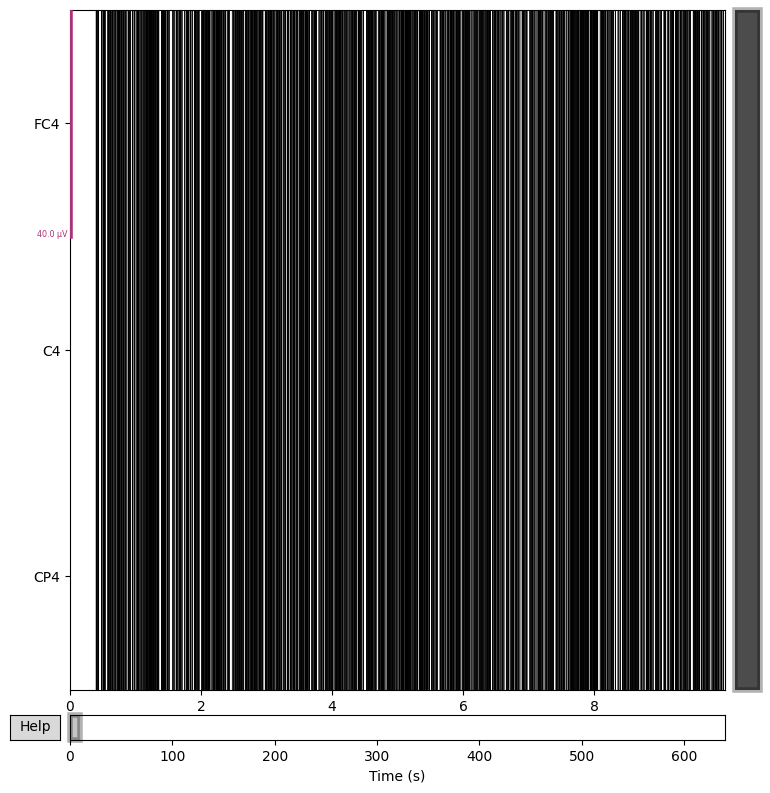

In [3]:
#now - identify electrodes involved in left hand movement - RIGHT HAND - FC4 - 9, C4 - 10, CP4 - 11
#index9= FC4, index10= C4, index11= CP4


#now - since we have an mne array - we can apply notch filter!!
array_cleaned = labeledarray.copy().filter(1,40).notch_filter(60)

# 3. Now plot that same motor strip trial
rightmotorstrip = array_cleaned.pick(['FC4', 'C4', 'CP4'])
rms_plot = rightmotorstrip.copy().plot()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 13 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 13.00 Hz
- Upper transition bandwidth: 3.25 Hz (-6 dB cutoff frequency: 14.62 Hz)
- Filter length: 845 samples (1.650 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 13 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 13.00
- Lower transition bandwidth: 3.25 Hz (-6 dB cutoff frequency: 11.38 Hz)
- Upper passband edge:

/tmp/ipython-input-2948784711.py:14: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd_mu_computed.plot()
/tmp/ipython-input-2948784711.py:15: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd_beta_computed.plot()


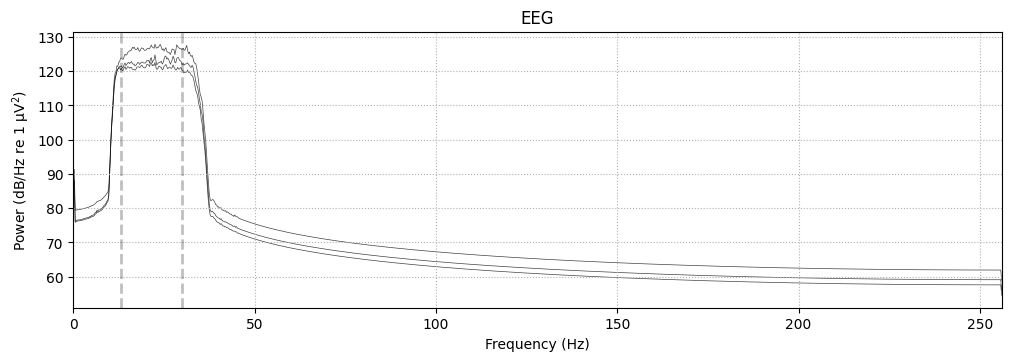

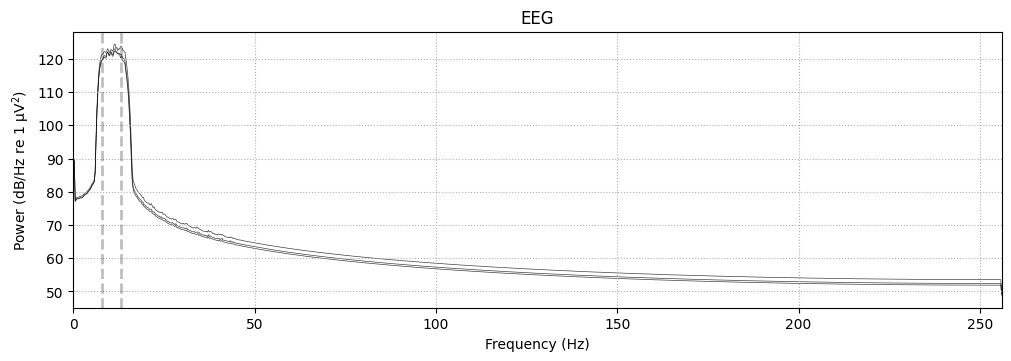

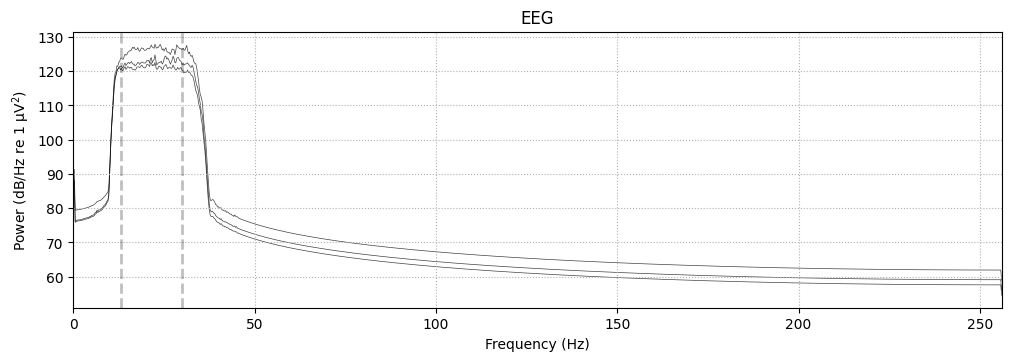

In [4]:
#now - we have to extract the psd from each electrode and plot it to look for the relevant ERDs

#SHOULD SEE PRONOUNCED DECREASE IN MU AND BETA PSD
#so now - we need to isolate mu and beta frequencies and plot the psd's of them

rms_mu = rightmotorstrip.copy().filter(l_freq=8.0, h_freq=13.0)
rms_beta = rightmotorstrip.copy().filter(l_freq=13.0, h_freq=30.0)

# Compute PSD for the selected channels in the mu band - exact same - we are just doing compute psd - and now its across all trials
psd_mu_computed = rms_mu.compute_psd()
# Compute PSD for the selected channels in the beta band
psd_beta_computed = rms_beta.compute_psd()

psd_mu_computed.plot()
psd_beta_computed.plot()

In [7]:
#next step - YOU NEED TO SEE WHAT THE AVERAGE PSD IS FOR MU AND BETA FREQUENCIES ACROSS ALL TRIALS - ISOLATE THE TRIALS WITH MOVEMENT OF LEFT - AND SHOW THE ERD% DROP

#now - by making it a raw array(numpy), it isn't indexing a specific trial anymore - this is the mu/beta psd across ALL TRIALS - so we have to segment it to see where the DROP occurs
#the drop comparison wil be WITHIN A TRIAL - preparation phase v execution - so the 0-2.5s and the 3.5-8

#we used mne io for the psd calculations - but using epochsarray will allow us to segment it out - so we stick to epochsarray cause the trials have already been segmented


# Create the info first (as you did)
info = mne.create_info(ch_names=channel_names, sfreq=sampling_freq, ch_types=channel_types)

# Define the dictionary
event_dict = {'Right_Hand': 1, 'Left_Hand': 2}

# Define the 3-column events array (80 rows for 80 trials)
# Column 3 is the most important: it's your 1s and 2s from the labels
import numpy as np


#make variables for rawdata and labels so we can access it to make the events matrix
rawdata = mat_data['RawEEGData']
labels = mat_data['Labels']

n_samples_per_epoch = rawdata.shape[2]
n_epochs = rawdata.shape[0]

events_matrix = np.zeros((n_epochs, 3), dtype=int)

#this is defining the 1st column of events_matrix - all the trials with the epoch they correspond to
events_matrix[:,0] = np.arange(n_epochs)*n_samples_per_epoch

#this is creating a flattened second column that has all the labels(eg. 1/2 for left and right hand trials)
events_matrix[:, 2] = labels.flatten()

# THE CONSTRUCTOR
epochs_segmented = mne.EpochsArray(
    data = rawdata * 1e-6,      # Your 3D cube (scaled to Volts)
    info = info,                # Your metadata
    events = events_matrix,     # The 3-column array
    event_id = event_dict,      # The dictionary
    tmin = -3.0                 # Matching the timing diagram start
)



Not setting metadata
80 matching events found
No baseline correction applied
0 projection items activated


In [14]:
#this is used to convert the output into a decimal value instead of ____e-6
import numpy as np
np.set_printoptions(suppress=True, precision=2)


#now - instead of getting mu and beta separately - we are going to get a sensorimotor rhythm in the 8-30 hz range that we will use for the threshold gate

contra_motorstrip = epochs_segmented.copy().pick(['FC4', 'C4', 'CP4'])
ipsi_motorstrip = epochs_segmented.copy().pick(['FC3', 'C3', 'CP3'])


contra_psd_baseline = contra_motorstrip.compute_psd(tmin=-3, tmax=-1.5, fmin=8, fmax=30)
contra_psd_sweetspot = contra_motorstrip.compute_psd(tmin=0.5, tmax=4.5, fmin=8, fmax=30)


ipsi_psd_baseline = ipsi_motorstrip.compute_psd(tmin=-3, tmax=-1.5, fmin=8, fmax=30)
ipsi_psd_sweetspot = ipsi_motorstrip.compute_psd(tmin=0.5, tmax=4.5, fmin=8, fmax=30)

#remember - now to calculate the erd drop, we want to make a spectrum with only the 8-30hz frequency - so you take mean for each trial across each of the 3 electrodes

baseline_contra= contra_psd_baseline.get_data().mean(axis = (1, 2))
sweetspot_contra = contra_psd_sweetspot.get_data().mean(axis = (1, 2))
erddrop_contra = ((sweetspot_contra - baseline_contra)/(baseline_contra))*100
print(erddrop_contra)

#now for ipsilateral side

baseline_ipsi= ipsi_psd_baseline.get_data().mean(axis = (1,2))
sweetspot_ipsi = ipsi_psd_sweetspot.get_data().mean(axis = (1,2))
erddrop_ipsi = ((sweetspot_ipsi - baseline_ipsi)/(baseline_ipsi))*100
print(erddrop_ipsi)

    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows
[   8.16  -34.38  -25.52   -9.34   -8.96  -15.32  -35.78    2.65  -16.25
  -20.09  -21.06  -17.73  -18.36  -18.7   316.53   -0.88   -7.08   -9.7
  -18.13    0.23  -13.36   29.62    5.67   -5.35   -2.82  -19.39   55.96
    4.67    4.35   19.9   -25.92  -16.61   -4.99   43.27   10.49  -13.79
   -3.24  -49.63  -21.85  -23.64  -17.65  -21.43   41.84  -22.43  -12.9
    3.42   -7.38   29.51   12.78   10.27   11.73   -4.49  -26.73   -2.43
   -9.15    6.82    0.71   -4.69  -11.1     0.53  -35.6    -7.13   12.15
 1187.82    2.82  -17.24    7.37  109.86    2.16  -17.67  -17.77  -42.8
   -6.42   32.46   -4.94   -6.23   -5.69  -23.61   -1.15  -35.45]
[ -19.59  -21.44   -9.1     2.73  -25.63   18.31   -9.76   -5.47   16.07
   -1.07  -26.28  -17.71  -18.8     

In [23]:
#now - we have to generate predictions based on the erd drop - WE MAKE OUR 2 TYPES OF THRESHOLD

#THRESHOLD 1(for patients with strong enough contralateral circuit - if erddrop_contra <= - 25%, then classify as [1]

#Threshold 2(for patients in critical stage who have rewired connections/need ipsilateral) - this is where lateralization index comes in

#li_value = (l-r)/(l+r)

#If you use if contra <= -25%: move_hand, else: check_LI, you create two problems:

#The "Cheater" gets through: If a patient has a -30% drop on the contralateral side but a -60% drop on the healthy side, your if statement sees the -30% first and moves the hand. You've just rewarded the brain for using the wrong side.

#False Positives in the Else: If the else (the LI logic) triggers without a power threshold, the glove might move just because the right side is 1% lower than the left, even if both sides are basically at rest.

li_value = (erddrop_ipsi - erddrop_contra)/(np.abs(erddrop_ipsi) + np.abs(erddrop_contra))
print(li_value)

predictions = []


#zip allows you to iterate between 2 lists - taking same index in both(and both are same length!!)
#.append adds the associated number
for contra, li in zip(erddrop_contra, li_value):
    if contra <= -25 and li < 0:
        predictions.append(2)
    else:
        predictions.append(1)


print(predictions)

[-1.    0.23  0.47  1.   -0.48  1.    0.57 -1.    1.    0.9  -0.11  0.
 -0.01  1.    0.51  1.    0.6   1.   -0.12  0.99  1.   -0.04  0.5   0.48
  1.    1.    0.02 -1.    0.86 -1.   -0.22  0.47 -0.48  0.24 -1.    1.
 -0.32  0.66  0.46  0.04  1.    1.   -0.04  1.   -0.24 -1.   -0.5  -1.
 -1.    0.26  0.56  1.   -0.18 -0.77  1.   -1.   -1.   -0.52  1.   -1.
 -0.14 -0.18 -1.    0.24 -1.   -0.5  -1.   -0.55 -1.   -0.48 -0.36  0.19
  0.19 -1.    0.62  0.96  0.07  0.42  0.42  0.25]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [24]:
#now - we want to see how accurate our gated model is


#ground truth - take labels from before - flatten it into a 1D list
ground_truth = labels.flatten()

#make predictions into a numpy array
predictions_array = np.array(predictions)


#this takes sum of the # of occurences where the prediction = the ground truth
matches = np.sum(predictions_array == ground_truth)

total_trials = len(ground_truth)
success_rate = (matches / total_trials) * 100

print(success_rate)
#the success rate can change based on adjustments to the threshold we make in streamlit

48.75


In [ ]:
# now - we need to wrap all of this code into a function that you can pass any file into(in this case, they are.mat, but it should also be able to tackle csv)
#so with the mat_data - we have a pipeline for processing matlab files
#now- we need to make one for csv

import scipy.io as sio
import pandas as pd
import mne
import numpy as np


CH_NAMES = ['FC3', 'C3', 'CP3', 'FC4', 'C4', 'CP4']
SFREQ = 250


def load_mat_data(file_path, file_type = 'mat'):
  mat_data = sio.loadmat(file_path)
  raw_data = mat_data['RawEEGData']
  labels = mat_data['Labels']
  return raw_data, labels



def load_csv_to_mne(csv_file, sfreq=250):
    # 1. Read the CSV
    df = pd.read_csv(csv_file)
    data = df[CH_NAMES].values.T # MNE expects (n_channels, n_samples
    data = data * 1e-6
    info = mne.create_info(ch_names = CH_NAMES, sfreq = SFREQ, ch_types='eeg')
    raw_data= mne.io.RawArray(data, info)

    return raw_data


def calculate_psd(epochs_segmented):
    # Split into Contra and Ipsi
    contra_motorstrip = epochs_segmented.copy().pick(['FC4', 'C4', 'CP4'])
    ipsi_motorstrip = epochs_segmented.copy().pick(['FC3', 'C3', 'CP3'])

    # Compute PSDs
    c_base = contra_motorstrip.compute_psd(tmin=-3, tmax=-1.5, fmin=8, fmax=30).get_data().mean(axis=(1, 2))
    c_task = contra_motorstrip.compute_psd(tmin=0.5, tmax=4.5, fmin=8, fmax=30).get_data().mean(axis=(1, 2))

    i_base = ipsi_motorstrip.compute_psd(tmin=-3, tmax=-1.5, fmin=8, fmax=30).get_data().mean(axis=(1, 2))
    i_task = ipsi_motorstrip.compute_psd(tmin=0.5, tmax=4.5, fmin=8, fmax=30).get_data().mean(axis=(1, 2))

    # ERD Calculations
    erddrop_contra = ((c_task - c_base) / c_base) * 100
    erddrop_ipsi = ((i_task - i_base) / i_base) * 100

    return erddrop_contra, erddrop_ipsi

def success_rate(erddrop_ipsi, erddrop_contra, labels):
    li_value = (erddrop_ipsi - erddrop_contra) / (np.abs(erddrop_ipsi) + np.abs(erddrop_contra))

    predictions = []
    for contra, li in zip(erddrop_contra, li_value):
        # Your Veto Gate logic
        if contra <= -25 and li < 0:
            predictions.append(2) # Intent Detected
        else:
            predictions.append(1) # Veto / Rest

    matches = np.sum(np.array(predictions) == labels.flatten())
    rate = (matches / len(labels)) * 100
    return rate


#THIS IS THE START OF THE PIPELINE - NOW THAT ALL FUNCTIONS HAVE BEEN DEFINED

def braintrain_pipeline(file_path, file_type='mat'):
    # A. LOAD
    if file_type == 'mat':
        raw_data, labels = load_mat_data(file_path)
        info = mne.create_info(ch_names=CH_NAMES, sfreq=SFREQ, ch_types='eeg')

        events_matrix = np.zeros((len(labels), 3), dtype=int)
        events_matrix[:, 0] = np.arange(len(labels)) * 1000
        events_matrix[:, 2] = labels.flatten()

        epochs = mne.EpochsArray(data=raw_data*1e-6, info=info, events=events_matrix, tmin=-3.0)

    else: # CSV Logic
        raw_mne = load_csv_to_mne(file_path)
        events = mne.make_fixed_length_events(raw_mne, duration=8.0)
        # We assume labels are '1' (Rest) for unknown CSVs or pass them in
        labels = np.ones(len(events))
        epochs = mne.Epochs(raw_mne, events, tmin=-3.0, tmax=4.5, baseline=(-3.0, -1.5), preload=True)

    # B. ERDDROP
    drop_c, drop_i = calculate_psd(epochs)

    # C. SUCCESS
    acc = success_rate(drop_c, drop_i, labels)

    return acc

# --- 4. THE GRAND LOOP ---

results_table = {}
for i in range(1, 11):
    file_name = f"parsed_P{i:02d}T.mat"
    try:
        accuracy = braintrain_pipeline(file_name, file_type='mat')
        results_table[f"Participant_{i}"] = accuracy
        print(f"P{i} Accuracy: {accuracy:.2f}%")
    except Exception as e:
        print(f"Skipping P{i}: {e}")

print("\nFinal Results:", results_table)





